In [13]:
import pandas as pd
import numpy as np
import re
import sys
import os
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EMAIL PHISHING MODEL TRAINING")
print("="*60)

# Add project root to path for imports
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Load the email dataset - contains email text and phishing labels
print("\nLoading dataset...")
df = pd.read_csv('../data/raw/phishing_email.csv', on_bad_lines='skip')
df.dropna(subset=['text_combined'], inplace=True)
print(f"Loaded {len(df)} emails")
print(f"Distribution: {df['label'].value_counts().to_dict()}")

EMAIL PHISHING MODEL TRAINING

Loading dataset...
Loaded 82486 emails
Distribution: {1: 42891, 0: 39595}


In [14]:
print("="*60)
print("FEATURE EXTRACTION")
print("="*60)

# Define keyword lists for detecting common phishing tactics
# These capture social engineering patterns used in phishing emails
URGENCY_KEYWORDS = ["urgent", "immediately", "act now", "final notice", "suspended", 
                    "locked", "verify now", "action required", "expire", "deadline", "last chance"]
CREDENTIAL_KEYWORDS = ["password", "pin", "one-time", "otp", "security code", 
                       "verification code", "ssn", "social security", "credit card", "bank account"]
THREAT_KEYWORDS = ["account will be", "suspended", "terminated", "closed", "unauthorized", "unusual activity"]
REWARD_KEYWORDS = ["congratulations", "winner", "won", "prize", "lottery", "inheritance", "million dollars"]

def extract_email_text_features(text):
    """Extract phishing indicators from email text content."""
    text_lower = text.lower() if isinstance(text, str) else ""
    features = {}
    
    # Social engineering indicators
    features['has_urgency'] = int(any(kw in text_lower for kw in URGENCY_KEYWORDS))
    features['has_credential_words'] = int(any(kw in text_lower for kw in CREDENTIAL_KEYWORDS))
    
    # "Click here" combined with links is a strong phishing signal
    has_click_here = "click here" in text_lower or "click below" in text_lower
    has_link = bool(re.search(r'https?://\S+', text_lower))
    features['has_click_here_link'] = int(has_click_here and has_link)
    
    # Link analysis
    links = re.findall(r'https?://\S+', text_lower)
    features['link_count'] = len(links)
    features['has_many_links'] = int(len(links) >= 5)
    
    # Threat and reward language (fear/greed manipulation)
    features['has_threat_words'] = int(any(kw in text_lower for kw in THREAT_KEYWORDS))
    features['has_reward_words'] = int(any(kw in text_lower for kw in REWARD_KEYWORDS))
    
    # Text statistics
    features['text_length'] = len(text_lower)
    features['word_count'] = len(text_lower.split())
    features['exclamation_count'] = text_lower.count('!')
    features['question_count'] = text_lower.count('?')
    features['caps_ratio'] = sum(1 for c in text if c.isupper()) / max(1, len(text))
    features['has_dollar_amount'] = int(bool(re.search(r'\$[\d,]+', text)))
    features['has_phone_number'] = int(bool(re.search(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', text)))
    
    return features

# Apply feature extraction to all emails
print("Extracting text features...")
text_features_list = df['text_combined'].apply(extract_email_text_features).tolist()
text_features_df = pd.DataFrame(text_features_list)
print(f"Extracted {len(text_features_df.columns)} features")

# TF-IDF converts text to numerical features based on word importance
# Using bigrams (ngram_range=(1,2)) captures phrases like "verify account"
print("\nVectorizing with TF-IDF...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5, 
                             max_df=0.95, stop_words='english', sublinear_tf=True)
X_tfidf = vectorizer.fit_transform(df['text_combined'])
print(f"TF-IDF shape: {X_tfidf.shape}")

# Combine TF-IDF features with our custom text features for a hybrid approach
print("\nCombining features...")
X_text_features = csr_matrix(text_features_df.values)
X_combined = hstack([X_tfidf, X_text_features])
print(f"Combined shape: {X_combined.shape}")

y = df['label']

FEATURE EXTRACTION
Extracting text features...
Extracted 14 features

Vectorizing with TF-IDF...
TF-IDF shape: (82486, 10000)

Combining features...
Combined shape: (82486, 10014)


MODEL COMPARISON
Training: 65988, Testing: 16498

5-Fold Cross-Validation:
--------------------------------------------------
Random Forest: Acc=0.9853, F1=0.9859
Logistic Regression: Acc=0.9721, F1=0.9733
Gradient Boosting: Acc=0.9436, F1=0.9473
Multinomial NB: Acc=0.9019, F1=0.8980


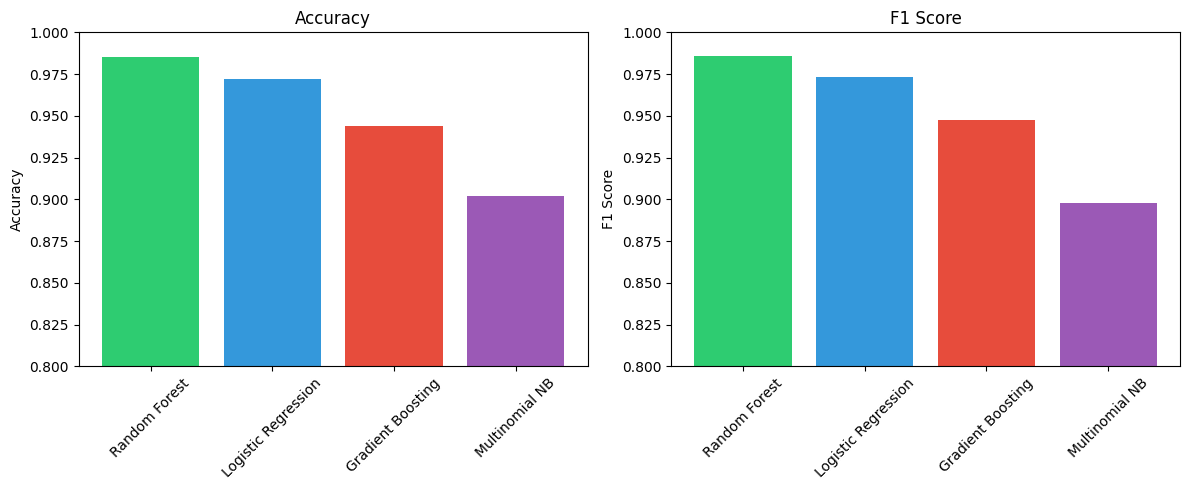


Best Model: Random Forest


In [15]:
print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Stratified split maintains the same class ratio in train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {X_train.shape[0]}, Testing: {X_test.shape[0]}")

# Compare different classifiers to find the best approach for email classification
models = {
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Multinomial NB': MultinomialNB()  # Traditional baseline for text classification
}

# 5-fold cross-validation gives more reliable performance estimates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("\n5-Fold Cross-Validation:")
print("-" * 50)

for name, model in models.items():
    try:
        acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
        results.append({'Model': name, 'acc_mean': acc_scores.mean(), 'f1_mean': f1_scores.mean()})
        print(f"{name}: Acc={acc_scores.mean():.4f}, F1={f1_scores.mean():.4f}")
    except Exception as e:
        print(f"{name}: Error - {e}")

# Visualize model comparison
results_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (col, title) in zip(axes, [('acc_mean', 'Accuracy'), ('f1_mean', 'F1 Score')]):
    bars = ax.bar(results_df['Model'], results_df[col], color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0.8, 1.0)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"\nBest Model: {results_df.loc[results_df['f1_mean'].idxmax(), 'Model']}")

TF-IDF vs HYBRID COMPARISON

Training TF-IDF only...
Training Hybrid...

TF-IDF Only:  Acc=0.9865, F1=0.9871
Hybrid:       Acc=0.9864, F1=0.9870
Improvement:  Acc +-0.01%, F1 +-0.01%


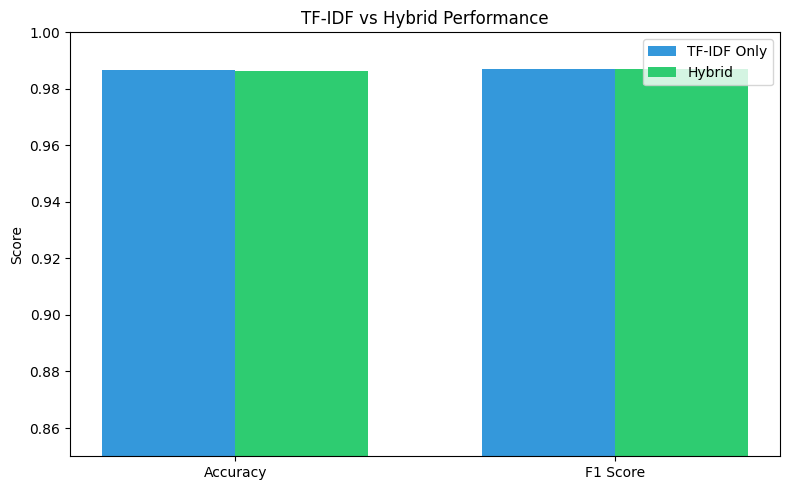

In [16]:
print("="*60)
print("TF-IDF vs HYBRID COMPARISON")
print("="*60)

# Compare TF-IDF only vs hybrid (TF-IDF + custom features)
# This validates whether our custom features add value

print("\nTraining TF-IDF only...")
rf_tfidf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)
preds_tfidf = rf_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, preds_tfidf)
f1_tfidf = f1_score(y_test, preds_tfidf)

print("Training Hybrid...")
rf_hybrid = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf_hybrid.fit(X_train, y_train)
preds_hybrid = rf_hybrid.predict(X_test)
proba_hybrid = rf_hybrid.predict_proba(X_test)[:, 1]
acc_hybrid = accuracy_score(y_test, preds_hybrid)
f1_hybrid = f1_score(y_test, preds_hybrid)

print(f"\nTF-IDF Only:  Acc={acc_tfidf:.4f}, F1={f1_tfidf:.4f}")
print(f"Hybrid:       Acc={acc_hybrid:.4f}, F1={f1_hybrid:.4f}")
print(f"Improvement:  Acc +{(acc_hybrid-acc_tfidf)*100:.2f}%, F1 +{(f1_hybrid-f1_tfidf)*100:.2f}%")

# Visualize the comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [acc_tfidf, f1_tfidf], width, label='TF-IDF Only', color='#3498db')
ax.bar(x + width/2, [acc_hybrid, f1_hybrid], width, label='Hybrid', color='#2ecc71')
ax.set_ylabel('Score')
ax.set_title('TF-IDF vs Hybrid Performance')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score'])
ax.legend()
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

ROC-AUC ANALYSIS

ROC-AUC: 0.9988, Avg Precision: 0.9989


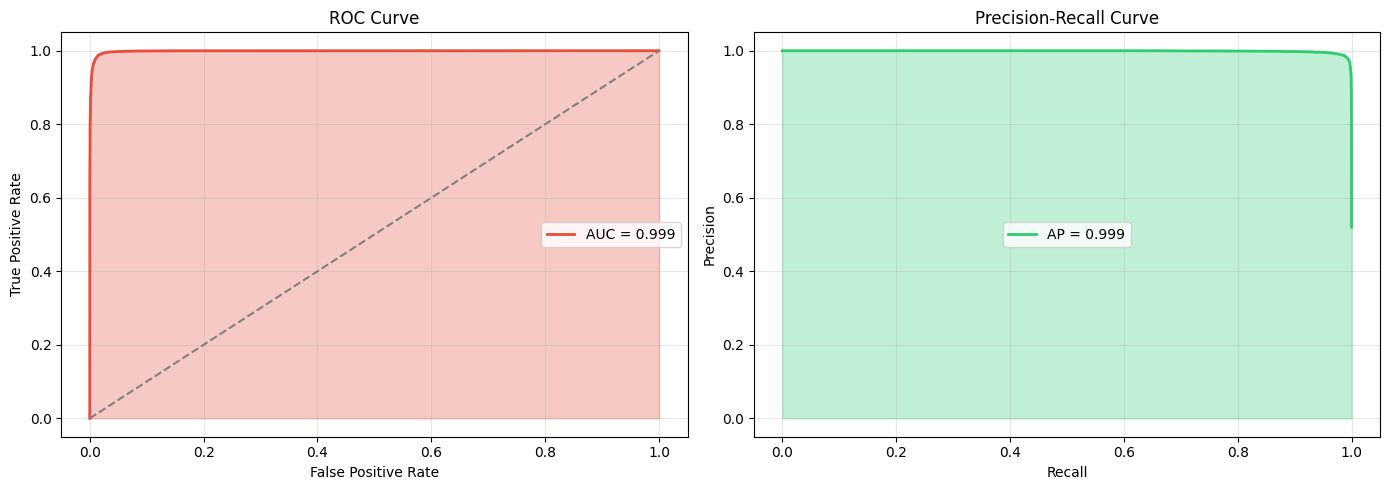


--- Classification Report ---
              precision    recall  f1-score   support

        Safe       0.99      0.98      0.99      7919
    Phishing       0.99      0.99      0.99      8579

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



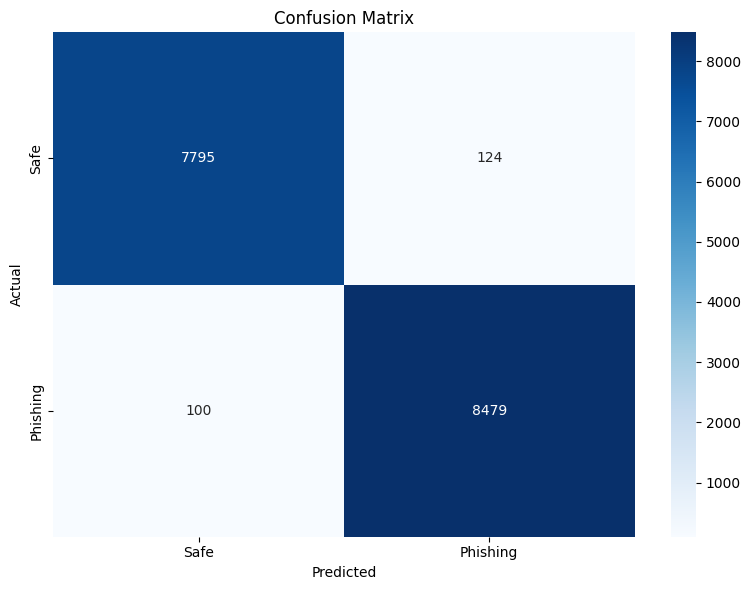

In [17]:
print("="*60)
print("ROC-AUC ANALYSIS")
print("="*60)

# ROC-AUC measures how well the model distinguishes between classes
# Average Precision summarizes the precision-recall curve
roc_auc = roc_auc_score(y_test, proba_hybrid)
avg_precision = average_precision_score(y_test, proba_hybrid)

print(f"\nROC-AUC: {roc_auc:.4f}, Avg Precision: {avg_precision:.4f}")

# Plot ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve - closer to top-left corner is better
fpr, tpr, _ = roc_curve(y_test, proba_hybrid)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve - more informative for imbalanced datasets
precision, recall, _ = precision_recall_curve(y_test, proba_hybrid)
axes[1].plot(recall, precision, color='#2ecc71', lw=2, label=f'AP = {avg_precision:.3f}')
axes[1].fill_between(recall, precision, alpha=0.3, color='#2ecc71')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Classification report shows per-class precision, recall, F1
print("\n--- Classification Report ---")
print(classification_report(y_test, preds_hybrid, target_names=['Safe', 'Phishing']))

# Confusion matrix visualizes prediction errors
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, preds_hybrid)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [18]:
import sklearn

print("="*60)
print("MODEL EXPORT")
print("="*60)

# Measure inference time for backend performance planning
print("\n--- Inference Time ---")
_ = rf_hybrid.predict(X_test[:10])  # Warm-up run
n_iterations = 100
single_sample = X_test[:1]

start_time = time.perf_counter()
for _ in range(n_iterations):
    _ = rf_hybrid.predict(single_sample)
avg_inference_ms = (time.perf_counter() - start_time) / n_iterations * 1000
print(f"Single prediction: {avg_inference_ms:.3f} ms")

for batch_size in [10, 100]:
    batch = X_test[:batch_size]
    start_time = time.perf_counter()
    _ = rf_hybrid.predict(batch)
    batch_time_ms = (time.perf_counter() - start_time) * 1000
    print(f"Batch of {batch_size}: {batch_time_ms:.2f} ms")

# Save model with all components needed for inference
# The package includes the model, vectorizer, and feature extraction function
print("\n--- Saving ---")
text_feature_names = list(text_features_df.columns)

email_model_package = {
    'model': rf_hybrid,
    'vectorizer': vectorizer,
    'text_feature_names': text_feature_names,
    'text_feature_extractor': extract_email_text_features,
    'metrics': {'accuracy': acc_hybrid, 'f1_score': f1_hybrid, 'roc_auc': roc_auc},
    'training_info': {
        'date': datetime.now().isoformat(),
        'sklearn_version': sklearn.__version__,
        'n_train': X_train.shape[0],
        'n_test': X_test.shape[0],
        'total_features': X_combined.shape[1]
    }
}

joblib.dump(email_model_package, '../data/processed/email_model.joblib')
joblib.dump(vectorizer, '../data/processed/tfidf_vectorizer.joblib')
print("Models saved to data/processed/")

print("\n" + "="*60)
print("BACKEND INFO")
print("="*60)
print(f"""
Model: Random Forest (TF-IDF + {len(text_feature_names)} text features)
Performance: Acc={acc_hybrid:.2%}, F1={f1_hybrid:.2%}, ROC-AUC={roc_auc:.4f}
Inference: ~{avg_inference_ms:.2f} ms

Usage:
  pkg = joblib.load('email_model.joblib')
  model, vectorizer = pkg['model'], pkg['vectorizer']
  extract_features = pkg['text_feature_extractor']
  
  tfidf_vec = vectorizer.transform([email_text])
  text_feats = pd.DataFrame([extract_features(email_text)])
  X = hstack([tfidf_vec, csr_matrix(text_feats.values)])
  prediction = model.predict(X)
""")

MODEL EXPORT

--- Inference Time ---
Single prediction: 22.588 ms
Batch of 10: 17.11 ms
Batch of 100: 28.48 ms

--- Saving ---
Models saved to data/processed/

BACKEND INFO

Model: Random Forest (TF-IDF + 14 text features)
Performance: Acc=98.64%, F1=98.70%, ROC-AUC=0.9988
Inference: ~22.59 ms

Usage:
  pkg = joblib.load('email_model.joblib')
  model, vectorizer = pkg['model'], pkg['vectorizer']
  extract_features = pkg['text_feature_extractor']

  tfidf_vec = vectorizer.transform([email_text])
  text_feats = pd.DataFrame([extract_features(email_text)])
  X = hstack([tfidf_vec, csr_matrix(text_feats.values)])
  prediction = model.predict(X)

